<a href="https://colab.research.google.com/github/OmarAwadSaber/Medical-Image-Diagnosis-System/blob/main/Phase3Fine_tune.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Evaluation Results:
{'eval_loss': 0.9394112825393677, 'eval_accuracy': 0.25, 'eval_precision': 0.0, 'eval_recall': 0.0, 'eval_f1': 0.0, 'eval_runtime': 0.0561, 'eval_samples_per_second': 71.307, 'eval_steps_per_second': 17.827, 'epoch': 3.0}


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classifi


Classification Report:
              precision    recall  f1-score   support

           0       0.25      1.00      0.40         1
           1       0.00      0.00      0.00         3

    accuracy                           0.25         4
   macro avg       0.12      0.50      0.20         4
weighted avg       0.06      0.25      0.10         4


Confusion Matrix:
[[1 0]
 [3 0]]


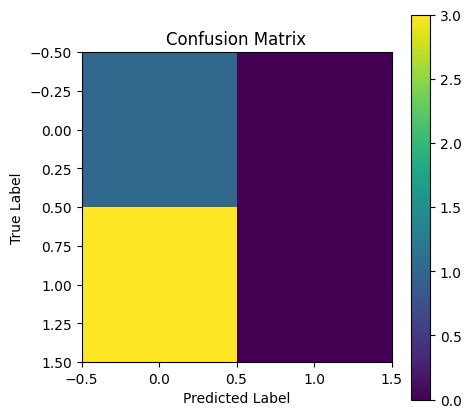

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Custom Prediction:
Negative Review


In [1]:

!pip install transformers datasets -q


import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

from torch.utils.data import Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

# =====================================
# Create Dataset
# =====================================

data = {
    "text": [
        "This movie was amazing",
        "I really loved this product",
        "Worst experience ever",
        "I hate this app",
        "Fantastic service and great quality",
        "Terrible customer support",
        "Very good and enjoyable",
        "Not worth the money",
        "Excellent performance",
        "Awful and disappointing",
        "Absolutely fantastic",
        "Very bad experience",
        "I enjoyed using this",
        "This is horrible",
        "Best thing I bought",
        "Waste of time"
    ],

    "label": [
        1, 1, 0, 0,
        1, 0, 1, 0,
        1, 0, 1, 0,
        1, 0, 1, 0
    ]
}

df = pd.DataFrame(data)

texts = df["text"].tolist()
labels = df["label"].tolist()

# =====================================
# Split Dataset
# =====================================

train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42
)

# =====================================
# Load Tokenizer
# =====================================

MODEL_NAME = "bert-base-uncased"

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

# =====================================
# Tokenization
# =====================================

train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=128
)

# =====================================
# Custom Dataset Class
# =====================================

class CustomDataset(Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(value[idx])
            for key, value in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):
        return len(self.labels)

# =====================================
# Create Dataset Objects
# =====================================

train_dataset = CustomDataset(
    train_encodings,
    train_labels
)

test_dataset = CustomDataset(
    test_encodings,
    test_labels
)

# =====================================
# Load BERT Model
# =====================================

model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

# =====================================
# Metrics Function
# =====================================

def compute_metrics(pred):

    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary"
    )

    accuracy = accuracy_score(labels, preds)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# =====================================
# Training Arguments
# =====================================

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=100,
    weight_decay=0.01,
    logging_steps=10
)

# =====================================
# Trainer
# =====================================

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# =====================================
# Train Model
# =====================================

trainer.train()

# =====================================
# Evaluate Model
# =====================================

results = trainer.evaluate()

print("\nEvaluation Results:")
print(results)

# =====================================
# Predictions
# =====================================

predictions = trainer.predict(test_dataset)

predicted_labels = np.argmax(
    predictions.predictions,
    axis=1
)

# =====================================
# Classification Report
# =====================================

print("\nClassification Report:")

print(
    classification_report(
        test_labels,
        predicted_labels
    )
)

# =====================================
# Confusion Matrix
# =====================================

cm = confusion_matrix(
    test_labels,
    predicted_labels
)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(5, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar()

plt.show()

# =====================================
# Save Model
# =====================================

model.save_pretrained("./fine_tuned_bert")

tokenizer.save_pretrained("./fine_tuned_bert")

# =====================================
# Test Custom Sentence
# =====================================

sample_text = "This movie was amazing"

inputs = tokenizer(
    sample_text,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=128
)

# Move Model and Inputs to Same Device

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)

inputs = {
    key: value.to(device)
    for key, value in inputs.items()
}

# Prediction

outputs = model(**inputs)

prediction = torch.argmax(
    outputs.logits,
    dim=1
).item()

print("\nCustom Prediction:")

if prediction == 1:
    print("Positive Review")

else:
    print("Negative Review")